<a href="https://colab.research.google.com/github/TomerL44/CloudCompEX/blob/main/Project/GreenZebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Install firebase-admin
!pip install firebase-admin -q

import requests
import nltk
import firebase_admin
from firebase_admin import credentials, firestore
from nltk.stem import WordNetLemmatizer
from collections import defaultdict

# Download necessary NLTK data quietly
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [25]:
import json
import firebase_admin
from firebase_admin import credentials, firestore
from google.colab import userdata

# FORCE DELETE THE OLD CACHED CONNECTION
if firebase_admin._apps:
    print("Disconnecting old Firebase app...")
    firebase_admin.delete_app(firebase_admin.get_app())

# Retrieve the JSON string from Colab Secrets
firebase_secret_string = userdata.get('FIREBASE_CREDENTIALS')
firebase_credentials_dict = json.loads(firebase_secret_string)
print(f"Connecting to project: {firebase_credentials_dict.get('project_id')}...")

# Initialize Firebase with the NEW credentials
cred = credentials.Certificate(firebase_credentials_dict)
firebase_admin.initialize_app(cred)

db = firestore.client()
print("Connected to Firebase Firestore successfully!")

Disconnecting old Firebase app...
Connecting to project: greenzebra-7892b...
Connected to Firebase Firestore successfully!


In [ ]:
#Document Download
#==RUN ONLY ONCE WHEN CREATING INDEX==
document_sources = {
    1: {
        "original_url": "https://www.frontiersin.org/journals/plant-science/articles/10.3389/fpls.2022.1051348/full",
        "drive_download_url": "https://drive.google.com/uc?export=download&id=1mVxZKYMKzhYyNmf_FipVxwx4EEu0txGn"
    },
    2: {
        "original_url": "https://www.tandfonline.com/doi/full/10.1080/14620316.2020.1727782",
        "drive_download_url": "https://drive.google.com/uc?export=download&id=1V5496mhH6sbDt4gNKkbJ8LnAnCKhI1FS"
    },
    3: {
        "original_url": "https://link.springer.com/article/10.1007/s40011-012-0107-0",
        "drive_download_url": "https://drive.google.com/uc?export=download&id=1vMumWjWA7V67VcPcfcM6FatnIpQCzkik"
    },
    4: {
        "original_url": "https://www.sciencedirect.com/science/article/pii/S0031942211000744",
        "drive_download_url": "https://drive.google.com/uc?export=download&id=1m8jnX-z_48s4gZayQEYKwX3qiHpaJ3eX"
    },
    5: {
        "original_url": "https://journal.unesa.ac.id/index.php/inajet/article/view/33340",
        "drive_download_url": "https://drive.google.com/uc?export=download&id=1IxOiJNs0v3LO8sR7F6xCdQUigXm_jow-"
    }
}

documents = {}
print("Downloading article texts from Google Drive...")

for doc_id, info in document_sources.items():
    try:
        response = requests.get(info["drive_download_url"])
        response.raise_for_status()
        documents[doc_id] = {
            "url": info["original_url"],
            "text": response.text
        }
    except Exception as e:
        print(f"ERROR: Failed to download Document {doc_id}.")
print("All documents downloaded successfully.\n" + "-" * 50)

All documents downloaded successfully.
--------------------------------------------------


In [ ]:
STOP_WORDS = {
    "a","an","and","are","as","at","be","by","for","from","in","is","it","of","on","the","to","with",
    "based","using","what","how","who","which","why","when","where","this","that","these","those",
    "they","them","their","we","our","can","will","do","has","have","would","should","could",
}

In [ ]:
#==RUN ONLY ONCE WHEN CREATING INDEX==
import math
from collections import Counter

#Building TF-IDF index
lemmatizer = WordNetLemmatizer()

def _tokenize(text):
    cleaned = text.lower().translate(str.maketrans('.,()[]:;/', '         '))
    return [lemmatizer.lemmatize(w) for w in cleaned.split() if w not in STOP_WORDS and len(w) > 2]

# Step 1: tokenize all documents
doc_tokens = {}
for doc_id, doc_info in documents.items():
    if not doc_info.get('text'): continue
    tokens = _tokenize(doc_info['text'])
    doc_tokens[doc_id] = {
        'url': doc_info['url'],
        'token_counts': Counter(tokens),
        'total_tokens': max(len(tokens), 1)
    }

N = len(doc_tokens)

# Step 2: document frequency (how many docs contain each term)
df = defaultdict(int)
for data in doc_tokens.values():
    for term in data['token_counts']:
        df[term] += 1

# Step 3: smoothed IDF
idf_scores = {term: math.log((N + 1) / (cnt + 1)) + 1 for term, cnt in df.items()}

# Step 4: build TF-IDF index
tfidf_index = defaultdict(list)
for doc_id, data in doc_tokens.items():
    for term, count in data['token_counts'].items():
        tf = count / data['total_tokens']
        score = round(tf * idf_scores[term], 8)
        if score > 0:
            tfidf_index[term].append({'doc_id': doc_id, 'url': data['url'], 'tfidf': score})

print(f'TF-IDF index built: {len(tfidf_index)} unique terms across {N} documents')


TF-IDF index built: 5659 unique terms across 5 documents


In [ ]:
#==RUN ONLY ONCE WHEN CREATING INDEX==
print('Filtering TF-IDF index to stay under Firebase limits...')

# The free tier allows 20,000 writes/day. We cap it at 15,000 to be safe.
MAX_TERMS = 15000

# Sort terms by Document Frequency (df) in descending order.
# This keeps words that appear in the most documents, dropping rare typos/numbers.
sorted_terms = sorted(df.keys(), key=lambda t: df[t], reverse=True)

# Keep only the top MAX_TERMS
allowed_terms = set(sorted_terms[:MAX_TERMS])

# Create a new, filtered dictionary
filtered_tfidf_index = {
    term: docs for term, docs in tfidf_index.items()
    if term in allowed_terms
}

print(f"Reduced vocabulary from {len(tfidf_index)} to {len(filtered_tfidf_index)} terms.")
print('Uploading filtered TF-IDF index to Firebase...')
print('-' * 50)

# Upload to Firebase
tfidf_ref = db.collection('orchid_tfidf')
batch = db.batch()
batch_count = 0
total = 0

for term, doc_scores in filtered_tfidf_index.items():
    # Guard against empty strings or slashes which crash Firestore
    if '/' in term or not term.strip(): continue

    batch.set(tfidf_ref.document(term), {
        'term': term,
        'idf': round(idf_scores[term], 6),
        'docs': doc_scores
    })

    batch_count += 1
    total += 1

    # Commit in batches of 499 (Firestore limit is 500 per batch)
    if batch_count >= 499:
        batch.commit()
        batch = db.batch()
        batch_count = 0

# Commit any remaining items
if batch_count > 0:
    batch.commit()

print(f'TF-IDF upload complete! {total} terms safely indexed.')
print('-' * 50)

Filtering TF-IDF index to stay under Firebase limits...
Reduced vocabulary from 5659 to 5659 terms.
Uploading filtered TF-IDF index to Firebase...
--------------------------------------------------
TF-IDF upload complete! 5659 terms safely indexed.
--------------------------------------------------



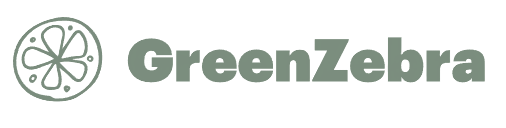

FaaS Invoke (Analytics): Plant Status is Optimal
Total FaaS invocations so far: 1



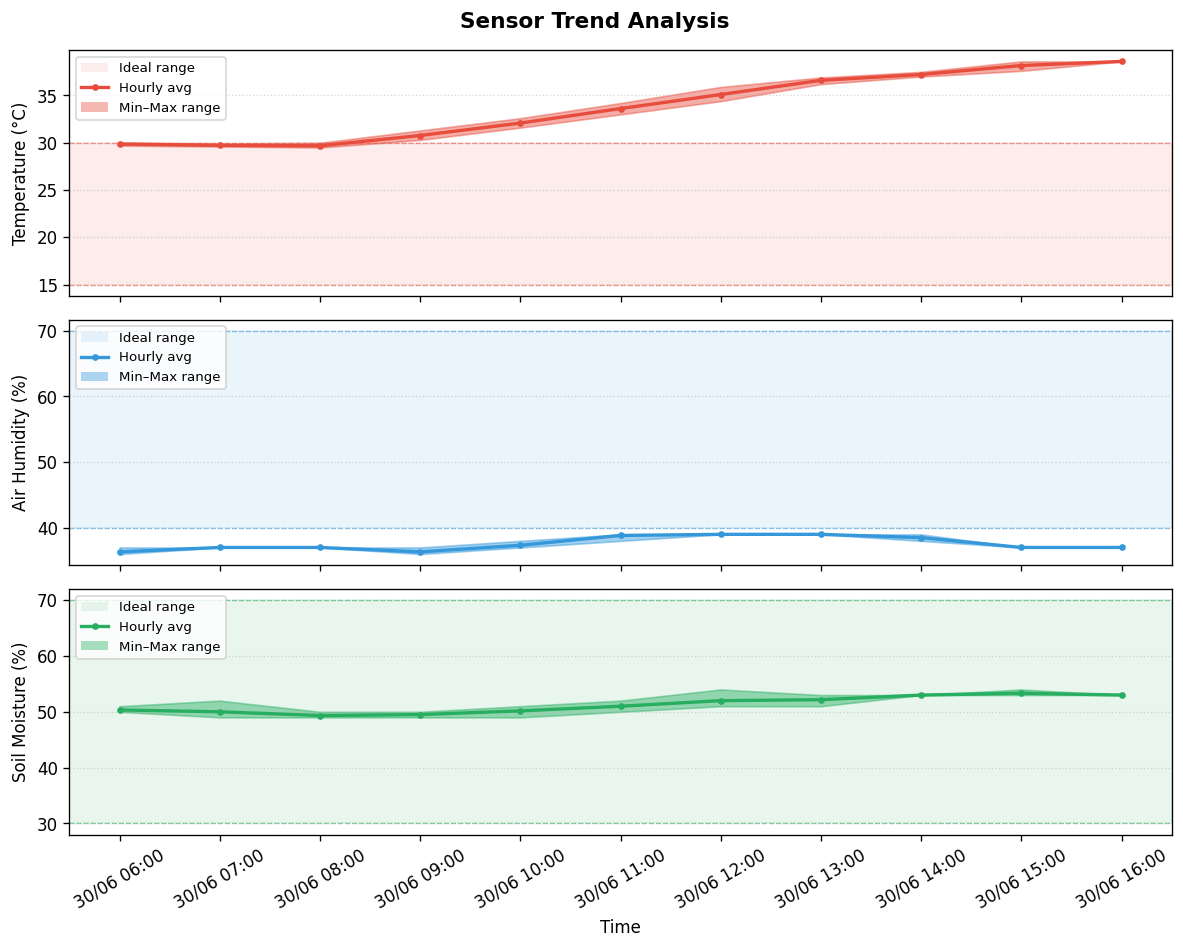

In [26]:
#  The Green Zebra
!pip install -q transformers datasets accelerate evaluate google-generativeai > /dev/null 2>&1

# quiet startup: hide install logs, HF download bars, and deprecation warnings
import os, warnings, logging
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"]      = "1"
os.environ["TRANSFORMERS_VERBOSITY"]            = "error"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
warnings.filterwarnings("ignore")
for _n in ("transformers", "huggingface_hub", "google", "google.generativeai"):
    logging.getLogger(_n).setLevel(logging.ERROR)

import requests, json, firebase_admin
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import base64
from io import BytesIO
from collections import defaultdict
from datetime import datetime, timedelta, timezone
from IPython.display import HTML, display
from firebase_admin import firestore
from nltk.stem import WordNetLemmatizer
from google.colab import output as colab_output
from google.colab import userdata
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from PIL import Image
from transformers import pipeline
import pytz
import torch
import re



# ── Shared configuration ─────────────────────────────────────
BASE_URL = "https://server-cloud-v645.onrender.com"
GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
IL_TZ    = timezone(timedelta(hours=3))

THRESHOLDS = {
    "temperature": {"min": 15, "max": 30, "unit": "°C", "icon": "🌡️", "label": "Temperature"},
    "humidity":    {"min": 40, "max": 70, "unit": "%",  "icon": "💧", "label": "Air Humidity"},
    "soil":        {"min": 30, "max": 70, "unit": "%",  "icon": "🌱", "label": "Soil Moisture"},
}

ALERTS = {
    "temperature": {"low":  "🥶 Temperature too low – move the orchid away from cold windows",
                    "high": "🔥 Temperature too high – shade the orchid and keep away from heat sources"},
    "humidity":    {"low":  "💨 Air humidity too low – mist around the plant or use a humidifier",
                    "high": "🌫️ Air humidity too high – improve ventilation to prevent mold"},
    "soil":        {"low":  "🏜️ Soil moisture too low – watering recommended soon",
                    "high": "🌊 Soil moisture too high – stop watering, check drainage"},
}

ADVICE = {
    "temperature": {
        "low":  ("🥶", "Temperature too low",  "Move the orchid away from cold windows. Orchids thrive at 15–30 °C."),
        "high": ("🔥", "Temperature too high", "Provide shade and keep away from heat vents or direct sunlight."),
        "ok":   ("✅", "Temperature ideal",    "The ambient temperature is perfect for your orchid right now."),
    },
    "humidity": {
        "low":  ("💨", "Air too dry",          "Mist around the plant or use a humidifier nearby. Target 40–70%."),
        "high": ("🌫️", "Air too humid",        "Improve ventilation to prevent mould and root rot."),
        "ok":   ("✅", "Humidity perfect",     "Air humidity is ideal for healthy orchid growth."),
    },
    "soil": {
        "low":  ("🏜️", "Needs watering soon",  "Soil is dry — water your orchid when the top layer feels dry."),
        "high": ("🌊", "Overwatered",          "Stop watering and check pot drainage to prevent root rot."),
        "ok":   ("✅", "Moisture balanced",    "Soil moisture is ideal. No watering needed right now."),
    },
}

BADGES_DEF = [
    ("🌱", "Sprout",        "First care log", 1,  "total"),
    ("🌿", "Growing",       "3-day streak",   3,  "streak"),
    ("🌸", "Blooming",      "7-day streak",   7,  "streak"),
    ("🏆", "Master Grower", "30-day streak",  30, "streak"),
]

_lem = WordNetLemmatizer()


#Shared utilities
def _db():
    return firestore.client() if firebase_admin._apps else None

def _today():
    return datetime.now(IL_TZ).strftime("%Y-%m-%d")

def _js(s):
    return s.replace("\\", "\\\\").replace("`", "\\`").replace("${", "\\${")

def _inject(el_id, html):
    display(HTML(f"<script>document.getElementById('{el_id}').innerHTML=`{_js(html)}`;</script>"))


#SENSOR TAB: helpers
def fetch_sensor_data(feed, limit):
    try:
        r = requests.get(f"{BASE_URL}/history", params={"feed": feed, "limit": limit}, timeout=60)
        r.raise_for_status()
        return r.json().get("data", []), None
    except requests.exceptions.Timeout:
        return [], "Server timeout – it may be waking up, please try again."
    except Exception as e:
        return [], str(e)

def fmt_time(iso):
    try:
        ts = datetime.fromisoformat(iso.replace("Z", "+00:00")).astimezone(IL_TZ)
        return ts.strftime("%d/%m/%Y %H:%M:%S")
    except:
        return iso

def fmt_value(feed, raw):
    try:
        if feed == "json":
            p = json.loads(raw)
            return f"🌡️ {p.get('temperature','?')}°C &nbsp; 💧 {p.get('humidity','?')}% &nbsp; 🌱 {p.get('soil','?')}%"
        t = THRESHOLDS[feed]
        return f"{t['icon']} {float(raw):.1f}{t['unit']}"
    except:
        return str(raw)

def get_status(feed, raw):
    if feed not in THRESHOLDS:
        return True, ""
    t = THRESHOLDS[feed]
    ok = t["min"] <= float(raw) <= t["max"]
    return ok, "✅ OK" if ok else "⚠️ Out of range"

def build_sensor_html(feed, limit, samples):
    t = THRESHOLDS.get(feed)
    feed_label = t["label"] if t else "All Sensors"
    feed_icon  = t["icon"]  if t else "📦"
    now_str    = datetime.now(IL_TZ).strftime("%H:%M:%S")

    rows_html = ""
    for i, s in enumerate(samples, 1):
        raw = s.get("value", "?")
        if feed != "json":
            ok, status_label = get_status(feed, raw)
            row_cls = "row-ok" if ok else "row-warn"
        else:
            status_label, row_cls = "", ""
        rows_html += f"""
        <tr class="{row_cls}">
          <td class="px-4 py-2 text-gray-400 text-xs">{i}</td>
          <td class="px-4 py-2 text-gray-600 text-xs">{fmt_time(s.get('created_at',''))}</td>
          <td class="px-4 py-2 font-medium text-gray-800">{fmt_value(feed, raw)}</td>
          <td class="px-4 py-2 text-xs">{status_label}</td>
        </tr>"""

    summary_html, alert_html = "", ""
    if feed != "json":
        try:
            vals = [float(s["value"]) for s in samples]
            unit = t["unit"]
            avg  = sum(vals) / len(vals)
            summary_html = f"""
            <div class="grid grid-cols-3 gap-3">
              <div class="bg-gray-50 rounded-xl p-4 text-center">
                <p class="text-xs text-gray-400 mb-1">Average</p>
                <p class="text-lg font-semibold text-gray-800">{avg:.1f}{unit}</p>
              </div>
              <div class="bg-gray-50 rounded-xl p-4 text-center">
                <p class="text-xs text-gray-400 mb-1">Min</p>
                <p class="text-lg font-semibold text-gray-800">{min(vals):.1f}{unit}</p>
              </div>
              <div class="bg-gray-50 rounded-xl p-4 text-center">
                <p class="text-xs text-gray-400 mb-1">Max</p>
                <p class="text-lg font-semibold text-gray-800">{max(vals):.1f}{unit}</p>
              </div>
            </div>"""
            alert_set = set()
            for v in vals:
                if v < t["min"]:   alert_set.add(ALERTS[feed]["low"])
                elif v > t["max"]: alert_set.add(ALERTS[feed]["high"])
            if alert_set:
                items = "".join(
                    f'<div class="flex items-start gap-3 bg-yellow-50 border border-yellow-200 rounded-xl px-4 py-3">'
                    f'<span class="text-sm text-yellow-800">{a}</span></div>' for a in alert_set
                )
                alert_html = f'<p class="text-xs font-semibold text-yellow-700 uppercase tracking-wider">🔔 Recommendations</p>{items}'
            else:
                alert_html = '<div class="flex items-center gap-2 bg-green-50 border border-green-200 rounded-xl px-4 py-3 text-sm text-green-800">✅ All readings within the recommended range for your orchid</div>'
        except:
            pass

    return f"""
    <div class="flex flex-col gap-4">
      <div class="flex items-center justify-between flex-wrap gap-2">
        <div class="flex items-center gap-2">
          <span class="text-2xl">{feed_icon}</span>
          <div>
            <p class="text-sm font-semibold text-gray-800">{feed_label}</p>
            <p class="text-xs text-gray-400">Fetched at {now_str}</p>
          </div>
        </div>
        <span class="text-xs bg-green-50 text-green-800 border border-green-200 rounded-full px-3 py-1">{len(samples)} samples</span>
      </div>
      <div class="overflow-auto rounded-xl border border-gray-100">
        <table class="w-full text-sm">
          <thead class="bg-gray-50 text-xs uppercase text-gray-400 tracking-wider">
            <tr>
              <th class="px-4 py-3 text-left w-8">#</th>
              <th class="px-4 py-3 text-left">Time</th>
              <th class="px-4 py-3 text-left">Value</th>
              <th class="px-4 py-3 text-left">Status</th>
            </tr>
          </thead>
          <tbody>{rows_html}</tbody>
        </table>
      </div>
      {summary_html}
      <div class="flex flex-col gap-2">{alert_html}</div>
    </div>"""


#DASHBOARD TAB: helpers
def _fetch_latest(feed):
    try:
        r = requests.get(f"{BASE_URL}/history", params={"feed": feed, "limit": 1}, timeout=60)
        r.raise_for_status()
        data = r.json().get("data", [])
        return data[0] if data else None, None
    except requests.exceptions.Timeout:
        return None, "timeout"
    except Exception as e:
        return None, str(e)

def _card_advice(icon, title, body, is_ok):
    bg = "bg-green-50 border-green-200" if is_ok else "bg-yellow-50 border-yellow-200"
    tc = "text-green-800"               if is_ok else "text-yellow-800"
    return (
        f'<div class="border {bg} rounded-xl px-4 py-3 flex items-start gap-3">'
        f'<span class="text-xl mt-0.5">{icon}</span>'
        f'<div><p class="text-xs font-semibold {tc}">{title}</p>'
        f'<p class="text-xs text-gray-500 mt-0.5">{body}</p></div></div>'
    )

def _card_badge(icon, name, desc, earned):
    ring = "border-green-200 bg-green-50" if earned else "border-gray-200 bg-gray-50 opacity-40"
    lock = "" if earned else '<span class="text-[10px] text-gray-400">🔒</span>'
    return (
        f'<div class="border {ring} rounded-xl p-3 flex flex-col items-center gap-1 text-center">'
        f'<span class="text-2xl">{icon}</span>'
        f'<p class="text-xs font-semibold text-gray-700">{name}</p>'
        f'<p class="text-[10px] text-gray-400 leading-tight">{desc}</p>'
        f'{lock}</div>'
    )

def _build_overview_and_advice():
    hero_cards, advice_html, healthy = "", "", 0
    for feed, t in THRESHOLDS.items():
        sample, err = _fetch_latest(feed)
        has_data = not err and sample
        if has_data:
            raw  = float(sample["value"])
            ok   = t["min"] <= raw <= t["max"]
            healthy += int(ok)
            hval     = f"{raw:.1f}{t['unit']}"
            hstatus  = ('<span class="text-[11px] text-green-300">✅ OK</span>'
                        if ok else '<span class="text-[11px] text-yellow-300">⚠️ Out of range</span>')
            key  = "ok" if ok else ("low" if raw < t["min"] else "high")
            icon, title, body = ADVICE[feed][key]
            advice_html += _card_advice(icon, title, body, ok)
        else:
            hval, hstatus = "—", '<span class="text-[11px] text-white/40">No data</span>'
            advice_html += _card_advice("⏳", f"{t['label']} unavailable", "Could not fetch sensor data.", False)
        hero_cards += (
            f'<div class="flex-1 min-w-[100px] bg-white/10 border border-white/10 rounded-xl p-3 text-center">'
            f'<p class="text-xs text-green-300 mb-1">{t["icon"]} {t["label"]}</p>'
            f'<p class="text-2xl font-semibold text-white">{hval}</p>{hstatus}</div>'
        )
    score = int(healthy / len(THRESHOLDS) * 100)
    if   score == 100: si, sl = "🌿", "Excellent"
    elif score >= 67:  si, sl = "🌱", "Good"
    elif score >= 34:  si, sl = "⚠️",  "Needs attention"
    else:              si, sl = "🚨", "Critical"
    now = datetime.now(IL_TZ).strftime("%H:%M:%S")
    score_card = (
        f'<div class="flex-1 min-w-[100px] bg-white/20 border border-white/20 rounded-xl p-3 text-center">'
        f'<span class="text-3xl">{si}</span>'
        f'<p class="text-[11px] text-green-200 uppercase tracking-wider mt-1">Health Score</p>'
        f'<p class="text-3xl font-semibold text-white">{score}%</p>'
        f'<p class="text-[11px] text-green-200">{sl}</p></div>'
    )
    overview = (
        f'<div class="flex gap-3 flex-wrap">{score_card}{hero_cards}</div>'
        f'<p class="text-[11px] text-green-400 mt-2">Updated at {now}</p>'
    )
    return overview, advice_html

def _build_gamification():
    db = _db()
    if not db:
        return '<p class="text-sm text-red-500 py-2">Firebase not connected – run the Firebase cell first.</p>'
    docs  = list(db.collection("care_log").stream())
    dates = sorted(set(d.to_dict().get("date", "") for d in docs if d.to_dict().get("date")), reverse=True)
    total = len(docs)
    streak, expected = 0, _today()
    for d in dates:
        if d == expected:
            streak += 1
            prev     = datetime.strptime(d, "%Y-%m-%d") - timedelta(days=1)
            expected = prev.strftime("%Y-%m-%d")
        else:
            break
    next_ms, next_ref = 30, streak
    for _, _, _, t, kind in BADGES_DEF:
        ref = total if kind == "total" else streak
        if ref < t:
            next_ms, next_ref = t, ref
            break
    pct   = min(100, int(next_ref / next_ms * 100)) if next_ms else 100
    flame = "🔥" if streak > 0 else "💤"
    badge_html = "".join(
        _card_badge(i, n, desc, (total >= t if kind == "total" else streak >= t))
        for i, n, desc, t, kind in BADGES_DEF
    )
    return (
        '<div class="w-full flex flex-col gap-4">'
        '<div class="flex items-center gap-3 justify-center">'
        f'<div class="flex items-center justify-between flex-wrap gap-2 mb-3">'
        f'<div class="flex items-center gap-2"><span class="text-2xl">{flame}</span>'
        f'<div><p class="text-sm font-semibold text-gray-800">{streak}-day streak</p>'
        f'<p class="text-xs text-gray-400">{total} action{"s" if total != 1 else ""} total</p>'
        f'</div></div>'
        f'<div class="flex gap-2">'
        f'<button onclick="logCare(\'water\')" class="text-xs bg-blue-50 hover:bg-blue-100 text-blue-700 border border-blue-200 rounded-lg px-3 py-1.5 transition-all active:scale-95">💧 Watered</button>'
        f'<button onclick="logCare(\'check\')" class="text-xs bg-green-50 hover:bg-green-100 text-green-700 border border-green-200 rounded-lg px-3 py-1.5 transition-all active:scale-95">👁️ Checked</button>'
        f'</div></div>'
        f'<div class="flex items-center justify-between text-xs text-gray-400 mb-1">'
        f'<span>Next badge</span><span>{next_ref}/{next_ms}</span></div>'
        f'<div class="w-full bg-gray-100 rounded-full h-1.5 mb-3">'
        f'<div class="bg-[#3B6D11] h-1.5 rounded-full" style="width:{pct}%"></div></div>'
        f'<div class="grid grid-cols-4 gap-2">{badge_html}</div>'
        '</div>'
        + _points_banner() +
        '</div>'
    )

def _build_rag(query):
    import google.generativeai as _genai
    db = _db()
    if not db:
        return ('<div class="text-sm text-red-700 bg-red-50 border border-red-200 rounded-xl px-4 py-3">'
                '❌ Firebase not initialised – run the Firebase cell first.</div>')

    # Tokenize query with lemmatization
    query_terms = list(set(
        _lem.lemmatize(w.lower().strip('.,!?;:'))
        for w in query.split()
        if w.lower() not in STOP_WORDS and len(w) > 2
    ))
    if not query_terms:
        return ('<div class="text-sm text-yellow-700 bg-yellow-50 border border-yellow-200 rounded-xl px-4 py-3">'
                '⚠️ Query too short. Try: <em>orchid, humidity, disease, growth</em>.</div>')

    # TF-IDF scoring: accumulate per-term scores across documents
    doc_scores = defaultdict(float)
    doc_urls = {}
    for term in query_terms:
        ref = db.collection('orchid_tfidf').document(term).get()
        if ref.exists:
            for entry in ref.to_dict().get('docs', []):
                did = entry['doc_id']
                doc_scores[did] += entry.get('tfidf', 0.0)
                doc_urls[did] = entry.get('url', '#')

    if not doc_scores:
        return ('<div class="text-sm text-yellow-700 bg-yellow-50 border border-yellow-200 rounded-xl px-4 py-3">'
                '⚠️ No matching articles found. Try: <em>orchid, humidity, disease, growth</em>.</div>')

    # Rank all documents by cumulative TF-IDF score
    ranked = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)
    top_docs = ranked[:2]  # top-2 fed as context to the LLM

    # Fetch live IoT sensor readings
    iot_lines = []
    for feed in ['temperature', 'humidity', 'soil']:
        sample, err = _fetch_latest(feed)
        if sample and not err:
            val = float(sample['value'])
            t = THRESHOLDS[feed]
            if val < t['min']:   status = f"TOO LOW (ideal ≥{t['min']}{t['unit']})"
            elif val > t['max']: status = f"TOO HIGH (ideal ≤{t['max']}{t['unit']})"
            else:                status = 'OK'
            iot_lines.append(f"{t['label']}: {val:.1f}{t['unit']} — {status}")
    iot_block = '\n'.join(iot_lines) if iot_lines else 'Sensor data currently unavailable.'

    # Gather article excerpts for context (first 2500 chars per top doc)
    article_blocks = []
    for doc_id, score in top_docs:
        text = documents.get(doc_id, {}).get('text', '')[:2500]
        article_blocks.append(f'[Article {doc_id} | TF-IDF score: {score:.4f}]\n{text}')
    article_context = '\n\n---\n\n'.join(article_blocks)

    # Call Gemini API
    llm_answer = '⚠️ Set GEMINI_API_KEY to enable AI-generated answers.'
    if GEMINI_API_KEY:
        try:
            _genai.configure(api_key=GEMINI_API_KEY)
            gemini = _genai.GenerativeModel('gemini-2.5-flash')
            prompt = (
                'You are an expert orchid care assistant.\n'
                'Answer the user question using the research excerpts below as your primary knowledge source.\n'
                'Factor in the live IoT sensor readings to tailor your advice to the plant\'s actual current conditions.\n'
                'Be concise, practical, and use bullet points where helpful.\n'
                'Cite article numbers when referencing specific findings.\n\n'
                f'User question: {query}\n\n'
                f'Current sensor readings:\n{iot_block}\n\n'
                f'Research excerpts:\n{article_context}'
            )
            llm_answer = gemini.generate_content(prompt).text
        except Exception as e:
            llm_answer = f'⚠️ Gemini error: {str(e)}'

    # Markdown to HTML renderer for Gemini response
    def _md_to_html(text):
        import re as _re
        text = text.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
        text = _re.sub(r'\*\*(.*?)\*\*', r'<strong class="font-semibold text-gray-800">\1</strong>', text)
        lines = text.split('\n')
        parts = []
        in_list = False
        for line in lines:
            s = line.strip()
            is_bullet = s.startswith('* ') or s.startswith('- ') or s.startswith('• ')
            if is_bullet:
                if not in_list:
                    parts.append('<ul class="flex flex-col gap-1.5 my-1">')
                    in_list = True
                content = s[2:]
                parts.append(
                    '<li class="flex items-start gap-2 text-sm text-gray-700">'
                    '<span class="text-green-500 mt-0.5 shrink-0 font-bold">•</span>'
                    f'<span>{content}</span></li>'
                )
            else:
                if in_list:
                    parts.append('</ul>')
                    in_list = False
                if s == '':
                    parts.append('<div class="h-1.5"></div>')
                else:
                    parts.append(f'<p class="text-sm text-gray-700 leading-relaxed">{s}</p>')
        if in_list:
            parts.append('</ul>')
        return '\n'.join(parts)

    # Build HTML for Gemini Response
    formatted_answer = _md_to_html(llm_answer)
    answer_html = (
        '<div class="bg-white rounded-xl border border-gray-200 overflow-hidden shadow-sm">'
        '<div class="flex items-center gap-2 px-4 py-3 bg-gray-50 border-b border-gray-100">'
        '<span class="text-base">\U0001f916</span>'
        '<p class="text-xs font-semibold text-gray-500 uppercase tracking-wider">AI Answer</p>'
        '</div>'
        f'<div class="px-4 py-4 flex flex-col gap-1">{formatted_answer}</div>'
        '</div>'
    )

    iot_html = ''
    if iot_lines:
        def _iot_row(line):
            if 'TOO HIGH' in line:  icon, cls = '\U0001f525', 'border-red-200 bg-red-50 text-red-700'
            elif 'TOO LOW' in line: icon, cls = '\U0001f976', 'border-blue-200 bg-blue-50 text-blue-700'
            else:                   icon, cls = '✅', 'border-green-200 bg-green-50 text-green-700'
            return (f'<div class="flex items-center gap-2 rounded-lg border {cls} px-3 py-2">'
                    f'<span class="text-sm shrink-0">{icon}</span>'
                    f'<span class="text-xs font-medium">{line}</span></div>')
        rows = ''.join(_iot_row(l) for l in iot_lines)
        iot_html = (
            '<div class="bg-white rounded-xl border border-gray-200 overflow-hidden shadow-sm">'
            '<div class="flex items-center gap-2 px-4 py-3 bg-gray-50 border-b border-gray-100">'
            '<span class="text-base">\U0001f321️</span>'
            '<p class="text-xs font-semibold text-gray-500 uppercase tracking-wider">Live Sensor Context</p>'
            '</div>'
            f'<div class="px-4 py-3 flex flex-col gap-2">{rows}</div>'
            '</div>'
        )

    top_score = ranked[0][1] if ranked else 1
    badges = ''
    for rank_i, (doc_id, score) in enumerate(ranked, 1):
        url = doc_urls.get(doc_id, '#')
        bar = int(score / top_score * 100) if top_score > 0 else 0
        badges += (
            f'<a href="{url}" target="_blank"'
            f' class="flex items-center justify-between gap-3 px-3 py-2.5 rounded-lg'
            f' hover:bg-green-50 hover:border-green-200 border border-transparent transition-all group">'
            f'<div class="flex items-center gap-2.5 min-w-0">'
            f'<span class="text-[11px] font-bold text-gray-300 w-5">#{rank_i}</span>'
            f'<span class="text-xs font-medium text-gray-700 truncate">Article {doc_id}</span>'
            f'</div>'
            f'<div class="flex items-center gap-2 shrink-0">'
            f'<div class="w-14 bg-gray-100 rounded-full h-1.5 overflow-hidden">'
            f'<div class="bg-green-400 h-1.5 rounded-full" style="width:{bar}%"></div></div>'
            f'<span class="text-[10px] text-gray-400 w-9 text-right tabular-nums">{score:.4f}</span>'
            f'<span class="text-green-500 text-xs group-hover:translate-x-0.5 transition-transform">↗</span>'
            f'</div></a>'
        )
    sources_html = (
        '<div class="bg-white rounded-xl border border-gray-200 overflow-hidden shadow-sm">'
        '<div class="flex items-center justify-between px-4 py-3 bg-gray-50 border-b border-gray-100">'
        '<div class="flex items-center gap-2">'
        '<span class="text-base">\U0001f4c4</span>'
        f'<p class="text-xs font-semibold text-gray-500 uppercase tracking-wider">{len(ranked)} Sources — TF-IDF Ranked</p>'
        '</div>'
        f'<span class="text-[10px] text-gray-400 italic truncate max-w-[160px]">&ldquo;{query}&rdquo;</span>'
        '</div>'
        f'<div class="px-2 py-1.5 flex flex-col gap-0.5">{badges}</div>'
        '</div>'
    )

    return f'<div class="flex flex-col gap-3">{answer_html}{iot_html}{sources_html}</div>'

def _build_chart():
    firestore_db = _db()
    if not firestore_db:
        return '<p class="text-sm text-red-500">Firebase not connected.</p>'
    col_ref = firestore_db.collection("sensor_readings")
    rawRecords = []
    for doc in col_ref.stream():
        d = doc.to_dict()
        rawRecords.append({
            "feed":       d.get("feed"),
            "value":      d.get("value", 0),
            "created_at": d.get("created_at", ""),
        })
    if not rawRecords:
        return '<p class="text-sm text-yellow-600">No sensor data in DB yet – fetch sensors first.</p>'

    # map phase
    mapped = defaultdict(list)
    for r in rawRecords:
        mapped[r["feed"]].append({"timestamp": r["created_at"], "value": r["value"]})

    hourlyResults = {}
    for feed, entries in mapped.items():
        df = pd.DataFrame(entries)
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        df = df.set_index("timestamp").sort_index()
        # reduce phase
        result = df.resample("h").agg(
            mean=("value","mean"), vmin=("value","min"), vmax=("value","max")
        ).dropna()
        hourlyResults[feed] = result

    PLOT_CONFIG = {
        "temperature": {"label": "Temperature (°C)", "color": "#E74C3C", "min": 15, "max": 30},
        "humidity":    {"label": "Air Humidity (%)",  "color": "#3498DB", "min": 40, "max": 70},
        "soil":        {"label": "Soil Moisture (%)", "color": "#27AE60", "min": 30, "max": 70},
    }

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle("Sensor Trend Analysis", fontsize=13, fontweight="bold")

    for ax, (feed, cfg) in zip(axes, PLOT_CONFIG.items()):
        if feed not in hourlyResults or hourlyResults[feed].empty:
            ax.text(0.5, 0.5, f"No data for {feed}", ha="center", va="center",
                    transform=ax.transAxes, color="gray")
            ax.set_ylabel(cfg["label"], fontsize=10)
            continue
        hourly = hourlyResults[feed]
        x = hourly.index
        ax.axhspan(cfg["min"], cfg["max"], alpha=0.10, color=cfg["color"], label="Ideal range")
        ax.axhline(cfg["min"], color=cfg["color"], linewidth=0.8, linestyle="--", alpha=0.5)
        ax.axhline(cfg["max"], color=cfg["color"], linewidth=0.8, linestyle="--", alpha=0.5)
        ax.plot(x, hourly["mean"], color=cfg["color"], linewidth=2, marker="o", markersize=3, label="Hourly avg")
        ax.fill_between(x, hourly["vmin"], hourly["vmax"], alpha=0.45, color=cfg["color"], label="Min–Max")
        ax.set_ylabel(cfg["label"], fontsize=10)
        legend_elements = [
            Patch(facecolor=cfg["color"], alpha=0.10, label="Ideal range"),
            Line2D([0], [0], color=cfg["color"], linewidth=2, marker="o", markersize=3, label="Hourly avg"),
            Patch(facecolor=cfg["color"], alpha=0.40, label="Min–Max range"),
        ]
        ax.legend(handles=legend_elements, fontsize=8, loc="upper left")
        ax.grid(axis="y", linestyle=":", alpha=0.5)

    il_tz = pytz.timezone("Asia/Jerusalem")

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %H:%M", tz=il_tz))
    axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator(tz=il_tz, maxticks=12))
    axes[-1].set_xlabel("Time", fontsize=10)
    plt.xticks(rotation=30)
    plt.tight_layout()

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=120, bbox_inches="tight")
    plt.close()
    buf.seek(0)
    img64 = base64.b64encode(buf.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{img64}" style="width:100%;border-radius:12px;">'

# =================================
# MICROSERVICES (FaaS) ARCHITECTURE
# =================================
import json

class GreenZebraGatewayFaaS:
    def __init__(self):
        self.services = {}
        self.invocations = 0

    def register_service(self, service_name, service_function):
        self.services[service_name] = service_function

    def invoke(self, service_name, payload):
        self.invocations += 1
        if service_name not in self.services:
            raise ValueError(f"Service '{service_name}' not found.")
        input_data = json.loads(json.dumps(payload))
        response = self.services[service_name](input_data)
        return json.loads(json.dumps(response))

# Microservice 1: Analytics
def analytics_health_service(data):
    moisture_history = data.get("moisture_history", [])
    if not moisture_history:
        return {"health_status": "Unknown", "avg": 0}
    avg_moisture = sum(moisture_history) / len(moisture_history)
    status = "Optimal"
    if avg_moisture < 30: status = "Needs Water"
    elif avg_moisture > 70: status = "Overwatered"
    return {"health_status": status, "avg_moisture": round(avg_moisture, 2)}

# Microservice 2: Gamification
def gamification_rewards_service(data):
    action = data.get("action")
    xp_matrix = {"water": 15, "check": 5}
    xp_gained = xp_matrix.get(action, 10)
    return {"action_processed": action, "xp_gained": xp_gained, "service": "Gamification_v1"}

# Initialize Gateway and Register Services
faas_gateway = GreenZebraGatewayFaaS()
faas_gateway.register_service("analytics", analytics_health_service)
faas_gateway.register_service("gamification", gamification_rewards_service)

# Callbacks
def cb_fetch_data(feed, limit):
    samples, err = fetch_sensor_data(feed, limit)
    if err:
        result_html = f'<div class="text-sm text-red-700 bg-red-50 border border-red-200 rounded-xl px-4 py-3">❌ {err}</div>'
    elif not samples:
        result_html = '<div class="text-sm text-yellow-700 bg-yellow-50 border border-yellow-200 rounded-xl px-4 py-3">⚠️ No samples found.</div>'
    else:
        firestore_db = _db()
        if firestore_db and feed != "json":
            col_ref = firestore_db.collection("sensor_readings")
            moisture_vals = []

            for s in samples:
                val = float(s.get("value", 0))
                if feed == "soil":
                    moisture_vals.append(val)
                docId = f"{feed}_{s.get('id', s.get('created_at', ''))}"
                col_ref.document(docId).set({
                    "feed":       feed,
                    "value":      val,
                    "created_at": s.get("created_at", ""),
                    "saved_at":   datetime.now(IL_TZ).isoformat(),
                })

            # FAAS INTEGRATION (Microservice 1: Analytics)
            if feed == "soil" and moisture_vals:
                ms_result = faas_gateway.invoke("analytics", {"moisture_history": moisture_vals})
                print(f"FaaS Invoke (Analytics): Plant Status is {ms_result['health_status']}")
                print(f"Total FaaS invocations so far: {faas_gateway.invocations}")

        result_html = build_sensor_html(feed, limit, samples)
    _inject("sensor-results", result_html)

def cb_clear_results(_=None):
    display(HTML("<script>document.getElementById('sensor-results').innerHTML='';</script>"))

def cb_dash_refresh(_=None):
    overview, advice = _build_overview_and_advice()
    _inject("dash-overview", overview)
    _inject("dash-advice",   advice)

def cb_dash_load_gamification(_=None):
    _inject("dash-gamification", _build_gamification())

def cb_dash_log_care(action):
    # FAAS INTEGRATION (Microservice 2: Gamification)
    payload = {"action": action}
    ms_result = faas_gateway.invoke("gamification", payload)
    print(f"FaaS Invoke (Gamification): {ms_result}")

    db = _db()
    if db:
        db.collection("care_log").add({
            "action":    action,
            "date":      _today(),
            "timestamp": datetime.now(IL_TZ).isoformat(),
            "xp_gained": ms_result["xp_gained"] # Saved from Microservice
        })
    _inject("dash-gamification", _build_gamification())

def cb_dash_rag(query):
    spinner_on = "<script>document.getElementById('rag-spinner').classList.remove('hidden');</script>"
    display(HTML(spinner_on))
    html = _build_rag(query)
    script = (
        "<script>"
        "document.getElementById('rag-spinner').classList.add('hidden');"
        f"document.getElementById('rag-results').innerHTML=`{_js(html)}`;"
        "</script>"
    )
    display(HTML(script))

def cb_dash_clear_rag(_=None):
    script = (
        "<script>"
        "document.getElementById('rag-results').innerHTML='';"
        "document.getElementById('rag-input').value='';"
        "document.getElementById('rag-spinner').classList.add('hidden');"
        "</script>"
    )
    display(HTML(script))

colab_output.register_callback("fetch_data",             cb_fetch_data)
colab_output.register_callback("clear_results",          cb_clear_results)
def cb_show_chart(_=None):
    _inject("sensor-chart", _build_chart())

colab_output.register_callback("show_chart",             cb_show_chart)
colab_output.register_callback("dash_refresh",           cb_dash_refresh)
colab_output.register_callback("dash_load_gamification", cb_dash_load_gamification)
colab_output.register_callback("dash_log_care",          cb_dash_log_care)
colab_output.register_callback("dash_rag",               cb_dash_rag)
colab_output.register_callback("dash_clear_rag",         cb_dash_clear_rag)

#Chatbot
_POINTS      = {"water": 10, "check": 5}
_CHAT_POINTS = 5

_ASSISTANT_PROMPT = """
You are "The Green Zebra", a friendly AI assistant inside an orchid-care app.
Answer questions about caring for orchids (especially Phalaenopsis) and houseplants:
watering, light, humidity, temperature, repotting, pests and diseases.
Keep answers short, practical and beginner-friendly.
Healthy ranges: temperature 15-30C, air humidity 40-70%, soil moisture 30-70%.
If a question is unrelated to plants, gently steer back to plant care.
""".strip()

try:
    import google.generativeai as _genai_chat
    if not GEMINI_API_KEY:
        raise RuntimeError("GEMINI_API_KEY not set")
    _genai_chat.configure(api_key=GEMINI_API_KEY)
    _assistant = _genai_chat.GenerativeModel(
        "gemini-2.5-flash", system_instruction=_ASSISTANT_PROMPT
    ).start_chat(history=[])
except Exception as _e:
    _assistant = None

def _care_points():
    db = _db()
    if not db:
        return 0
    try:
        return sum(_POINTS.get(d.to_dict().get("action"), 0)
                   for d in db.collection("care_log").stream())
    except Exception:
        return 0

def _chat_points():
    db = _db()
    if not db:
        return 0
    try:
        snap = db.collection("app_rewards").document("chat").get()
        return snap.to_dict().get("points", 0) if snap.exists else 0
    except Exception:
        return 0

def _points_banner():
    pts   = _care_points() + _chat_points()
    level = pts // 50 + 1
    into  = pts % 50
    pct   = int(into / 50 * 100)
    return (
        '<div class="flex items-center justify-between gap-3 bg-[#EAF3DE] border border-green-200 rounded-xl px-4 py-3 mb-3">'
        '<div class="flex items-center gap-2"><span class="text-2xl">\u2b50</span>'
        f'<div><p class="text-sm font-semibold text-[#1a3d08]">Level {level}</p>'
        f'<p class="text-[11px] text-green-700">{pts} total points</p></div></div>'
        '<div class="flex flex-col items-end gap-1 min-w-[140px]">'
        f'<span class="text-[10px] text-gray-500">{into}/50 XP to Level {level + 1}</span>'
        '<div class="w-36 bg-white rounded-full h-1.5 border border-green-200">'
        f'<div class="bg-[#3B6D11] h-1.5 rounded-full" style="width:{pct}%"></div></div></div></div>'
    )

def _assistant_sources(question):
    db = _db()
    if not db:
        return []
    try:
        terms = {_lem.lemmatize(w.lower().strip(".,!?;:"))
                 for w in question.split()
                 if w.lower() not in STOP_WORDS and len(w) > 2}
        scores, urls = {}, {}
        for term in terms:
            ref = db.collection("orchid_tfidf").document(term).get()
            if ref.exists:
                for e in ref.to_dict().get("docs", []):
                    scores[e["doc_id"]] = scores.get(e["doc_id"], 0) + e.get("tfidf", 0)
                    urls[e["doc_id"]] = e.get("url", "#")
        return [(d, urls[d]) for d in sorted(scores, key=scores.get, reverse=True)[:3]]
    except Exception:
        return []

def _chat_bubble(text, sources):
    safe = text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
    safe = re.sub(r"\*\*(.+?)\*\*", r"<strong>\1</strong>", safe)
    rows = []
    for ln in safe.split("\n"):
        s = ln.strip()
        rows.append("\u2022 " + s[2:] if s[:2] in ("* ", "- ") else ln)
    safe = "<br>".join(rows)
    chips = ""
    if sources:
        chips = '<div class="flex flex-wrap gap-1 mt-1.5">' + "".join(
            f'<a href="{u}" target="_blank" class="text-[10px] text-green-700 bg-green-50 border border-green-200 rounded px-2 py-0.5">Article {d} \u2197</a>'
            for d, u in sources
        ) + "</div>"
    return ('<div class="flex justify-start mb-1"><div class="max-w-[80%] bg-gray-100 text-gray-800 text-sm rounded-2xl rounded-tl-sm px-4 py-2">'
            f'{safe}{chips}</div></div>')

def _award_chat_points():
    db = _db()
    if not db:
        return
    try:
        ref  = db.collection("app_rewards").document("chat")
        snap = ref.get()
        cur  = snap.to_dict().get("points", 0) if snap.exists else 0
        ref.set({"points": cur + _CHAT_POINTS})
    except Exception:
        pass

def cb_assistant(message):
    _award_chat_points()                          # reward for using the chatbot
    if _assistant is None:
        reply, srcs = ("The assistant isn't configured. Add GEMINI_API_KEY in Colab "
                       "Secrets and re-run this cell."), []
    else:
        try:
            reply = _assistant.send_message(message).text.strip()
            srcs  = _assistant_sources(message)
        except Exception as e:
            reply, srcs = f"Sorry, I couldn't reach the AI service ({e}).", []
    bubble  = _chat_bubble(reply, srcs)
    rewards = _points_banner()
    dash    = _build_gamification()               # keep the dashboard total in sync
    script = (
        "<script>(function(){"
        "var t=document.getElementById('assistant-typing'); if(t) t.remove();"
        "var box=document.getElementById('assistant-messages');"
        f"if(box){{box.insertAdjacentHTML('beforeend',`{_js(bubble)}`);box.scrollTop=box.scrollHeight;}}"
        f"var r=document.getElementById('assistant-rewards'); if(r) r.innerHTML=`{_js(rewards)}`;"
        f"var g=document.getElementById('dash-gamification'); if(g) g.innerHTML=`{_js(dash)}`;"
        "})();</script>"
    )
    display(HTML(script))

def cb_assistant_rewards(_=None):
    _inject("assistant-rewards", _points_banner())

colab_output.register_callback("assistant_send",    cb_assistant)
colab_output.register_callback("assistant_rewards", cb_assistant_rewards)

device = 0 if torch.cuda.is_available() else -1

orchid_classifier = pipeline(
    "image-classification",
    model="LeonSigal/orchid-cultivar-vit",
    device=device
)


# Hugging face
def resolve_orchid_name(label: str) -> str:
    """
    Extracts the species name from a label like 'class0000 (C. goeringii)'.
    Falls back to the raw label if the pattern doesn't match.
    """
    match = re.search(r"\((.*?)\)", label)
    return match.group(1) if match else label

orchid_classifier = pipeline(
    "image-classification",
    model="LeonSigal/orchid-cultivar-vit",
    device=0 if torch.cuda.is_available() else -1,
    token="HF_TOKEN"
)


def cb_scan_orchid(image_b64):
    try:

        img_data = base64.b64decode(image_b64.split(",")[-1])
        image = Image.open(BytesIO(img_data)).convert("RGB")


        orchid_predictions = orchid_classifier(image)
        best_orchid = orchid_predictions[0]
        orchid_display_name = resolve_orchid_name(best_orchid['label'])




        html = f"""
        <div class="bg-white border border-gray-100 rounded-xl p-4 mt-4 text-left w-full max-w-md mx-auto shadow-sm" dir="ltr">
            <h3 class="text-sm font-semibold text-gray-800 mb-2 uppercase tracking-wider">📋 Analysis Result</h3>
            <div class="flex flex-col gap-1.5">
                <p class="text-xs text-gray-600">
                    🌸 <b class="text-gray-700">Type:</b> {orchid_display_name}
                </p>
            </div>
        </div>
        """


        _inject("scan-result", html)
        return html

    except Exception as e:
        err_html = f'<div class="text-xs text-red-600 p-3 bg-red-50 rounded-xl max-w-md mx-auto mt-4 text-center">Error: {str(e)}</div>'
        _inject("scan-result", err_html)
        return err_html


colab_output.register_callback("scan_orchid", cb_scan_orchid)


# Master UI
# Download logo and embed as base64 (avoids CORS/Drive restrictions)
import base64 as _b64
try:
    _logo_r = requests.get(
        "https://drive.google.com/uc?export=download&id=10NxQ4PQOKSEgN_xWgsZzuXiw4mhBCVi9",
        timeout=15
    )
    _logo_src = "data:image/png;base64," + _b64.b64encode(_logo_r.content).decode()
except Exception as _e:
    _logo_src = ""
    print(f"Logo download failed: {_e}")

APP_HTML = r"""
<!DOCTYPE html>
<html lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>The Green Zebra</title>
<script src="https://cdn.tailwindcss.com"></script>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=DM+Sans:wght@300;400;500;600&display=swap" rel="stylesheet">
<style>
  body { font-family: 'DM Sans', sans-serif; margin: 0; padding: 0; background: #f9fafb; }

  .drop-zone.drag { border-color: #3B6D11; background: #EAF3DE; }
  .thumb { position: relative; width: 72px; height: 72px; border-radius: 10px; overflow: hidden; flex-shrink: 0; }
  .thumb img { width: 100%; height: 100%; object-fit: cover; }
  .thumb-remove { position: absolute; top: 3px; right: 3px; background: white; border: 1px solid #e5e7eb;
                  border-radius: 50%; width: 18px; height: 18px; display: flex; align-items: center;
                  justify-content: center; cursor: pointer; font-size: 10px; line-height: 1; color: #6b7280; }
  .thumb-remove:hover { background: #f3f4f6; }

  .sensor-btn { transition: all .15s; cursor: pointer; }
  .sensor-btn:hover { transform: translateY(-1px); }
  .sensor-btn.active { background: #3B6D11 !important; color: white !important; border-color: #3B6D11 !important; }
  .row-ok   { background: #f0fdf4; }
  .row-warn { background: #fffbeb; }

  .tab-btn { transition: all .15s; cursor: pointer; }
  .tab-btn.active { background: #3B6D11 !important; color: #ffffff !important; border-color: #3B6D11 !important; }

  .screen { display: none; width: 100%; }
  .screen.active { display: flex; flex-direction: column; gap: 1rem; align-items: center; }
</style>
</head>
<body class="bg-gray-50 min-h-screen flex flex-col items-center px-5 pt-5 pb-10 gap-3">

  <!-- Logo + Brand -->
  <header class="w-full max-w-4xl mx-auto flex justify-center items-center px-1 mb-3">
    <img src="__LOGO_SRC__" alt="GreenZebra logo" class="h-24 w-auto" onerror="this.style.display='none'">
  </header>

  <!-- Tabs — mb-3 gives breathing room below before content -->
  <nav class="w-full max-w-4xl mx-auto flex gap-2 mb-3">
    <button class="tab-btn active flex-1 flex items-center justify-center gap-1.5 py-2.5 px-3 rounded-xl text-sm font-medium bg-white text-gray-600 border border-gray-200 hover:bg-gray-50" data-tab="dashboard">
       Dashboard
    </button>
    <button class="tab-btn flex-1 flex items-center justify-center gap-1.5 py-2.5 px-3 rounded-xl text-sm font-medium bg-white text-gray-600 border border-gray-200 hover:bg-gray-50" data-tab="scanner">
       Orchid Type Scanner
    </button>
    <button class="tab-btn flex-1 flex items-center justify-center gap-1.5 py-2.5 px-3 rounded-xl text-sm font-medium bg-white text-gray-600 border border-gray-200 hover:bg-gray-50" data-tab="sensors">
      Live Sensors
    </button>
    <button class="tab-btn flex-1 flex items-center justify-center gap-1.5 py-2.5 px-3 rounded-xl text-sm font-medium bg-white text-gray-600 border border-gray-200 hover:bg-gray-50" data-tab="research">
      Research
    </button>
  </nav>

  <!-- ─── TAB: SCANNER ─────────────────────────────────── -->
  <div id="screen-scanner" class="screen max-w-4xl w-full mx-auto">
    <div class="w-full bg-white shadow-md p-6 flex flex-col gap-6 rounded-2xl border border-gray-100">
      <div class="flex flex-col items-center text-center gap-2">
        <div class="w-16 h-16 rounded-full bg-green-50 flex items-center justify-center text-3xl">🌸</div>
        <h1 class="text-2xl font-semibold text-gray-900">Orchid type scanner</h1>
        <p class="text-sm text-gray-400 leading-relaxed max-w-md">Upload a clear photo and we'll analyze your orchid's type</p>
      </div>

      <label class="drop-zone border-2 border-dashed border-gray-200 rounded-xl p-16 flex flex-col items-center justify-center gap-3 text-center cursor-pointer hover:bg-gray-50 hover:border-gray-300 transition-all" id="drop-zone">
        <span class="text-5xl">📸</span>
        <span class="text-base font-medium text-gray-700">Drop your photo here</span>
        <span class="text-xs text-gray-400">or click to browse · PNG, JPG up to 10 MB</span>
        <input type="file" accept="image/*" multiple id="file-input" class="hidden">
      </label>

      <div id="upload-error" class="hidden text-xs text-red-600 bg-red-50 border border-red-200 rounded-xl px-4 py-2.5 text-center font-medium"></div>

      <div id="preview-section" class="hidden flex-col gap-4">
        <div id="thumb-row" class="flex gap-2 flex-wrap justify-center"></div>
        <div id="file-name" class="text-xs text-gray-500 break-all text-center"></div>
        <div class="flex gap-3 max-w-xs mx-auto w-full">
          <button onclick="handleScan()" class="flex-1 bg-green-800 hover:bg-green-700 active:scale-[0.98] text-white font-medium text-sm py-2 px-4 rounded-xl transition-all">Scan orchid →</button>
          <button onclick="removeAllPhotos()" class="flex-1 bg-red-50 hover:bg-red-100 active:scale-[0.98] text-red-600 font-medium text-sm py-2 px-4 rounded-xl border border-red-200 transition-all">Remove</button>
        </div>
        <div id="scan-result" class="w-full"></div>
      </div>

      <div class="flex items-center gap-3">
        <div class="flex-1 h-px bg-gray-100"></div>
        <span class="text-xs text-gray-400 whitespace-nowrap">tips for a good scan</span>
        <div class="flex-1 h-px bg-gray-100"></div>
      </div>

      <div class="grid grid-cols-2 md:grid-cols-4 gap-3">
        <div class="flex items-center gap-3 bg-gray-50 rounded-xl p-4"><span class="text-xl">☀️</span><span class="text-xs text-gray-500 leading-snug">Good natural light, no flash</span></div>
        <div class="flex items-center gap-3 bg-gray-50 rounded-xl p-4"><span class="text-xl">🔍</span><span class="text-xs text-gray-500 leading-snug">Focus on leaves and roots</span></div>
        <div class="flex items-center gap-3 bg-gray-50 rounded-xl p-4"><span class="text-xl">🪴</span><span class="text-xs text-gray-500 leading-snug">Include the whole plant</span></div>
        <div class="flex items-center gap-3 bg-gray-50 rounded-xl p-4"><span class="text-xl">🌫️</span><span class="text-xs text-gray-500 leading-snug">Avoid heavy shadows</span></div>
      </div>
    </div>
  </div>

  <!-- ─── TAB: SENSORS ─────────────────────────────────── -->
  <div id="screen-sensors" class="screen max-w-4xl w-full mx-auto">
    <div class="w-full bg-white shadow-md rounded-2xl border border-gray-100 p-6 flex flex-col gap-6">
      <div class="flex flex-col items-center text-center gap-2">
        <div class="w-16 h-16 rounded-full bg-green-50 flex items-center justify-center text-3xl">📡</div>
        <h1 class="text-2xl font-semibold text-gray-900">IoT Sensor Sampling</h1>
        <p class="text-sm text-gray-400 max-w-md">Fetch live readings from your orchid's sensors in real time</p>
      </div>

      <div class="flex flex-col gap-2">
        <span class="text-xs font-medium text-gray-500 uppercase tracking-wider">Select sensor</span>
        <div class="flex gap-2 flex-wrap" id="sensor-btns">
          <button class="sensor-btn active border border-gray-200 rounded-xl px-4 py-2 text-sm font-medium text-gray-700 bg-gray-50" data-feed="temperature">🌡️ Temperature</button>
          <button class="sensor-btn border border-gray-200 rounded-xl px-4 py-2 text-sm font-medium text-gray-700 bg-gray-50" data-feed="humidity">💧 Air Humidity</button>
          <button class="sensor-btn border border-gray-200 rounded-xl px-4 py-2 text-sm font-medium text-gray-700 bg-gray-50" data-feed="soil">🌱 Soil Moisture</button>
          <button class="sensor-btn border border-gray-200 rounded-xl px-4 py-2 text-sm font-medium text-gray-700 bg-gray-50" data-feed="json">📦 All sensors</button>
        </div>
      </div>

      <div class="flex flex-col gap-2">
        <span class="text-xs font-medium text-gray-500 uppercase tracking-wider">Number of samples: <span id="limit-val" class="text-[#3B6D11] font-semibold">10</span></span>
        <input type="range" min="1" max="50" value="10" id="limit-slider"
          oninput="document.getElementById('limit-val').textContent=this.value"
          class="w-full accent-[#3B6D11]">
      </div>

      <div class="flex gap-3">
        <button id="fetch-btn" onclick="submitFetch()" class="flex-1 bg-green-800 hover:bg-green-700 active:scale-[0.98] text-white font-medium text-sm py-3 rounded-xl transition-all">Fetch readings →</button>
        <button onclick="google.colab.kernel.invokeFunction('clear_results', [], {})" class="flex-1 bg-red-50 hover:bg-red-100 active:scale-[0.98] text-red-600 font-medium text-sm py-3 rounded-xl border border-red-200 transition-all">Clear</button>
      </div>

      <button onclick="google.colab.kernel.invokeFunction('show_chart', [], {})"
        class="w-full bg-[#3B6D11] hover:bg-[#2e5a0d] active:scale-[0.98] text-white font-medium text-sm py-3 rounded-xl transition-all">
        📈 Show Trend Chart
      </button>

      <div id="sensor-chart" class="mt-2"></div>
      <div id="sensor-results"></div>
    </div>
  </div>

  <!-- ─── TAB: DASHBOARD ───────────────────────────────── -->
  <div id="screen-dashboard" class="screen active max-w-4xl w-full mx-auto">

    <!-- Hero card -->
    <div class="w-full bg-gradient-to-br from-[#1a3d08] to-[#4a8a1a] rounded-2xl p-6 shadow-lg flex flex-col gap-4">
      <div class="flex items-start justify-between gap-4 flex-wrap">
        <div class="flex items-center gap-3">
          <div class="w-12 h-12 rounded-full bg-white/10 flex items-center justify-center text-2xl">🪴</div>
          <div>
            <h1 class="text-xl font-semibold text-white">Your orchid dashboard</h1>
            <p class="text-xs text-green-300">Precision agriculture monitoring</p>
          </div>
        </div>
        <button onclick="loadSensors()" class="text-xs bg-white/15 hover:bg-white/25 text-white border border-white/20 rounded-lg px-4 py-2 transition-all active:scale-95">↻ Refresh sensors</button>
      </div>
      <div id="dash-overview">
        <div class="flex gap-3 flex-wrap">
          <div class="flex-1 min-w-[100px] bg-white/10 border border-white/10 rounded-xl p-3 text-center"><p class="text-xs text-green-300 mb-1">Health Score</p><p class="text-2xl font-semibold text-white/30">—</p></div>
          <div class="flex-1 min-w-[100px] bg-white/10 border border-white/10 rounded-xl p-3 text-center"><p class="text-xs text-green-300 mb-1">🌡️ Temperature</p><p class="text-2xl font-semibold text-white/30">—</p></div>
          <div class="flex-1 min-w-[100px] bg-white/10 border border-white/10 rounded-xl p-3 text-center"><p class="text-xs text-green-300 mb-1">💧 Air Humidity</p><p class="text-2xl font-semibold text-white/30">—</p></div>
          <div class="flex-1 min-w-[100px] bg-white/10 border border-white/10 rounded-xl p-3 text-center"><p class="text-xs text-green-300 mb-1">🌱 Soil Moisture</p><p class="text-2xl font-semibold text-white/30">—</p></div>
        </div>
        <p class="text-xs text-white/30 mt-2">Click "Refresh sensors" to load live data</p>
      </div>
    </div>

    <!-- AI Advice -->
    <div class="w-full bg-white shadow-sm rounded-2xl border border-gray-100 p-5 flex flex-col gap-3">
      <p class="text-xs font-semibold text-gray-400 uppercase tracking-wider">💡 AI Care Advice</p>
      <div id="dash-advice" class="text-sm text-gray-400 italic">Refresh sensors to generate advice…</div>
    </div>

    <!-- Care Tracker -->
    <div class="w-full bg-white shadow-sm rounded-2xl border border-gray-100 p-5 flex flex-col">
      <p class="text-xs font-semibold text-gray-400 uppercase tracking-wider mb-3">🎯 Care Tracker</p>
      <div id="dash-gamification" class="flex items-center gap-3 justify-center py-4">
        <div class="w-4 h-4 border-2 border-[#3B6D11] border-t-transparent rounded-full animate-spin"></div>
        <span class="text-xs text-gray-500">Loading care history…</span>
      </div>
    </div>
  </div>

  <!-- ─── TAB: RESEARCH ─────────────────────────────────── -->
  <div id="screen-research" class="screen max-w-4xl w-full mx-auto">
    <div class="w-full bg-white shadow-md rounded-2xl border border-gray-100 p-6 flex flex-col gap-6">

      <div class="flex flex-col items-center text-center gap-2">
        <div class="w-16 h-16 rounded-full bg-green-50 flex items-center justify-center text-3xl">🔬</div>
        <h1 class="text-2xl font-semibold text-gray-900">Research Query</h1>
        <p class="text-sm text-gray-400 max-w-md">Search across 5 indexed orchid research articles using our RAG system</p>
      </div>

      <div class="flex gap-2">
        <input type="text" id="rag-input" placeholder="e.g. orchid disease, humidity control, root growth…"
          class="flex-1 border border-gray-200 rounded-xl px-4 py-2.5 text-sm text-white-700 outline-none focus:border-[#3B6D11] transition-colors"
          onkeydown="if(event.key==='Enter') submitRag()">
        <button onclick="submitRag()" class="bg-[#3B6D11] hover:bg-[#2e5a0d] active:scale-[0.98] text-white font-medium text-sm px-5 py-2.5 rounded-xl transition-all">Search →</button>
        <button onclick="clearRag()" class="bg-red-50 hover:bg-red-100 active:scale-[0.98] text-red-500 text-sm px-4 py-2.5 rounded-xl border border-red-200 transition-all">✕</button>
      </div>

      <div id="rag-spinner" class="hidden flex items-center gap-3">
        <div class="w-4 h-4 border-2 border-[#3B6D11] border-t-transparent rounded-full animate-spin"></div>
        <span class="text-xs text-gray-500">Querying Firebase index…</span>
      </div>

      <div id="rag-results"></div>
    </div>
  </div>

  <!-- Floating chat widget (persists across all tabs) -->
  <div id="chat-fab-wrap" style="position:fixed; bottom:20px; right:20px; z-index:9999;">
    <div id="chat-popup" class="hidden" style="position:absolute; bottom:74px; right:0; width:370px; max-width:88vw;">
      <div class="bg-white rounded-2xl shadow-2xl border border-gray-200 flex flex-col overflow-hidden" style="height:480px;">
        <div class="flex items-center justify-between gap-2 px-4 py-3 bg-[#3B6D11] text-white">
          <div class="flex items-center gap-2">
            <span class="text-lg">🤖</span>
            <div>
              <p class="text-sm font-semibold leading-tight">Green Zebra Assistant</p>
              <p class="text-[10px] text-green-100 leading-tight">powered by Gemini AI</p>
            </div>
          </div>
          <button onclick="toggleChat()" class="text-white/80 hover:text-white text-lg leading-none">✕</button>
        </div>
        <div id="assistant-messages" class="flex-1 overflow-auto flex flex-col px-3 py-2 bg-gray-50">
          <div class="flex justify-start mb-1"><div class="max-w-[85%] bg-gray-100 text-gray-800 text-sm rounded-2xl rounded-tl-sm px-4 py-2">Hi! 🌿 I'm your Green Zebra assistant. Ask me about watering, light, humidity, pests, or anything plant-related.</div></div>
        </div>
        <div id="assistant-rewards" class="px-3 py-2 border-t border-gray-100 bg-white"></div>
        <div class="flex gap-2 p-3 border-t border-gray-100 bg-white">
          <input id="assistant-input" type="text" placeholder="Type your question…"
            class="flex-1 bg-gray-800 border border-gray-600 rounded-xl px-3 py-2 text-sm text-white placeholder-gray-400 outline-none focus:border-[#3B6D11]"
            onkeydown="if(event.key==='Enter') assistantSend()">
          <button onclick="assistantSend()" class="bg-[#3B6D11] hover:bg-[#2e5a0d] text-white text-sm font-medium px-4 py-2 rounded-xl">→</button>
        </div>
      </div>
    </div>
    <button id="chat-fab" onclick="toggleChat()" class="w-14 h-14 rounded-full bg-[#3B6D11] hover:bg-[#2e5a0d] shadow-lg flex items-center justify-center text-2xl text-white transition-all active:scale-95">🤖</button>
  </div>

<script>
/* ─── Tab switching ─────────────────────────────────────── */
document.querySelectorAll('.tab-btn').forEach(btn => {
  btn.addEventListener('click', () => {
    document.querySelectorAll('.tab-btn').forEach(b => b.classList.remove('active'));
    btn.classList.add('active');
    document.querySelectorAll('.screen').forEach(s => s.classList.remove('active'));
    document.getElementById('screen-' + btn.dataset.tab).classList.add('active');
    if (btn.dataset.tab === 'dashboard' && !window._dashLoaded) {
      window._dashLoaded = true;
      try { google.colab.kernel.invokeFunction('dash_load_gamification', [], {}); } catch(e) {}
    }
  });
});

/* ─── SCANNER logic ─────────────────────────────────────── */
const input    = document.getElementById('file-input');
const dropZone = document.getElementById('drop-zone');
const preview  = document.getElementById('preview-section');
const thumbRow = document.getElementById('thumb-row');

function showError(msg) {
  const err = document.getElementById('upload-error');
  err.textContent = msg;
  err.classList.remove('hidden');
  setTimeout(() => err.classList.add('hidden'), 4000);
}
function addThumbs(files) {
  const invalid = [...files].filter(f => !f.type.startsWith('image/'));
  if (invalid.length) { showError('Only image files are allowed (PNG, JPG, WEBP, etc.)'); return; }
  if (files.length > 1 || thumbRow.children.length >= 1) { showError('Only one image can be uploaded at a time.'); return; }
  document.getElementById('scan-result').innerHTML = '';   // ← חדש: מנקה תוצאה ישנה ברגע שמתחילים העלאה חדשה
  const file = files[0];
  if (file.size > 10 * 1024 * 1024) { showError('Maximum file size is 10 MB.'); return; }
  [...files].forEach(f => {
    const reader = new FileReader();
    reader.onload = e => {
      const wrap = document.createElement('div'); wrap.className = 'thumb';
      const img  = document.createElement('img');  img.src = e.target.result; img.alt = f.name;
      const btn  = document.createElement('button'); btn.className = 'thumb-remove';
      btn.innerHTML = '✕'; btn.setAttribute('type', 'button');
      btn.onclick = () => { wrap.remove(); if (!thumbRow.children.length) hidePreview(); };
      wrap.append(img, btn);
      thumbRow.appendChild(wrap);
      document.getElementById('file-name').textContent = f.name;
    };
    reader.readAsDataURL(f);
  });
  preview.classList.remove('hidden');
  preview.classList.add('flex');
}
function hidePreview() { preview.classList.add('hidden'); preview.classList.remove('flex'); }
function removeAllPhotos() {
  thumbRow.innerHTML = '';
  document.getElementById('file-name').textContent = '';
  document.getElementById('scan-result').innerHTML = '';
  hidePreview();
}
function handleScan() {
  const img = thumbRow.querySelector("img");
  if (!img) {
    alert("Please upload an image first");
    return;
  }
  document.getElementById('scan-result').innerHTML = '';
  google.colab.kernel.invokeFunction(
    'scan_orchid',
    [img.src],
    {}
  );
}

input.addEventListener('change', e => addThumbs(e.target.files));
dropZone.addEventListener('dragover',  e => { e.preventDefault(); dropZone.classList.add('drag'); });
dropZone.addEventListener('dragleave', ()  => dropZone.classList.remove('drag'));
dropZone.addEventListener('drop',      e  => { e.preventDefault(); dropZone.classList.remove('drag'); addThumbs(e.dataTransfer.files); });


/* ─── SENSOR logic ──────────────────────────────────────── */
let currentFeed = 'temperature';
document.getElementById('sensor-btns').addEventListener('click', e => {
  const btn = e.target.closest('.sensor-btn');
  if (!btn) return;
  document.querySelectorAll('.sensor-btn').forEach(b => b.classList.remove('active'));
  btn.classList.add('active');
  currentFeed = btn.dataset.feed;
});
function submitFetch() {
  const limit = document.getElementById('limit-slider').value;
  document.getElementById('sensor-results').innerHTML =
    '<div class="flex items-center gap-3 py-4">' +
    '<div class="w-5 h-5 border-2 border-green-700 border-t-transparent rounded-full animate-spin"></div>' +
    '<span class="text-sm text-gray-500">Fetching… (first request may take ~30s)</span></div>';
  google.colab.kernel.invokeFunction('fetch_data', [currentFeed, parseInt(limit)], {});
}

/* ─── DASHBOARD logic ───────────────────────────────────── */
function loadSensors() {
  document.getElementById('dash-overview').innerHTML =
    '<div class="flex items-center gap-3 py-2">' +
    '<div class="w-5 h-5 border-2 border-white border-t-transparent rounded-full animate-spin"></div>' +
    '<span class="text-sm text-green-300">Fetching sensor data… (may take ~30 s)</span></div>';
  document.getElementById('dash-advice').innerHTML =
    '<p class="text-xs text-gray-400 italic">Waiting for sensor data…</p>';
  google.colab.kernel.invokeFunction('dash_refresh', [], {});
}
function logCare(action) {
  document.getElementById('dash-gamification').innerHTML =
    '<div class="flex items-center gap-3 justify-center py-4">' +
    '<div class="w-4 h-4 border-2 border-[#3B6D11] border-t-transparent rounded-full animate-spin"></div>' +
    '<span class="text-xs text-gray-500">Saving…</span></div>';
  google.colab.kernel.invokeFunction('dash_log_care', [action], {});
}

/* ─── RESEARCH logic ────────────────────────────────────── */
function submitRag() {
  const q = document.getElementById('rag-input').value.trim();
  if (!q) return;
  document.getElementById('rag-spinner').classList.remove('hidden');
  document.getElementById('rag-results').innerHTML = '';
  google.colab.kernel.invokeFunction('dash_rag', [q], {});
}
function clearRag() { google.colab.kernel.invokeFunction('dash_clear_rag', [], {}); }

/* ASSISTANT logic */
function assistantSend() {
  const inp = document.getElementById('assistant-input');
  const msg = inp.value.trim();
  if (!msg) return;
  const box = document.getElementById('assistant-messages');
  const safe = msg.replace(/&/g,'&amp;').replace(/</g,'&lt;').replace(/>/g,'&gt;');
  box.insertAdjacentHTML('beforeend',
    '<div class="flex justify-end mb-1"><div class="max-w-[80%] bg-[#3B6D11] text-white text-sm rounded-2xl rounded-tr-sm px-4 py-2">' + safe + '</div></div>');
  box.insertAdjacentHTML('beforeend',
    '<div id="assistant-typing" class="flex justify-start mb-1"><div class="bg-gray-100 text-gray-400 text-sm rounded-2xl px-4 py-2">🌿 typing…</div></div>');
  box.scrollTop = box.scrollHeight;
  inp.value = '';
  google.colab.kernel.invokeFunction('assistant_send', [msg], {});
}

/* open / close the floating chat window */
function toggleChat() {
  const p = document.getElementById('chat-popup');
  const f = document.getElementById('chat-fab');
  if (p.classList.contains('hidden')) {
    p.classList.remove('hidden');
    f.innerHTML = '✕';
    const box = document.getElementById('assistant-messages');
    if (box) box.scrollTop = box.scrollHeight;
    const inp = document.getElementById('assistant-input');
    if (inp) inp.focus();
  } else {
    p.classList.add('hidden');
    f.innerHTML = '🤖';
  }
}

/* auto-load rewards (assistant) + care tracker (dashboard) on first render */
setTimeout(function () {
  try { google.colab.kernel.invokeFunction('assistant_rewards', [], {}); } catch (e) {}
  if (!window._dashLoaded) {
    window._dashLoaded = true;
    try { google.colab.kernel.invokeFunction('dash_load_gamification', [], {}); } catch (e) {}
  }
}, 600);

</script>
</body>
</html>
"""

APP_HTML = APP_HTML.replace("__LOGO_SRC__", _logo_src)
display(HTML(APP_HTML))